ES I : POWER SCALING

Use CAMB to calculate the linear matter power spectrum for the reference cosmological parameters. Derive and verify the analytic scaling of the different regions of the power spectrum, overplot them. It might be useful to spline interpolate and differentiate the log power spectrum wrt to log k to obtain power law indexes.

THEORETICAL BACKGROUND: the matter power spectrum P(k) quantifies the distribution of matter density fluctuations in Fourier space.  
It has a broken power-law structure, whose shape arises from the time of horizon entry of each mode:  
 1)at large scale ($k<<keq$) the modes enter the horizon during matter domination, so they grow freely: $P(K)=k$  
 2)at small scale ($k>>keq$) the modes enter during radiation domination, where growth is suppressed due to radiation pressure: $P(K)=k^-3$  
 3)This transition at k=keq (the scale corresponding to matter-radiation equality) defines the characteristic turnover in the power spectrum.

In [37]:
import camb
from camb import model, initialpower
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import UnivariateSpline

# Parametri cosmologici di riferimento 
pars = camb.CAMBparams()
pars.set_cosmology(H0=67.5, ombh2=0.022, omch2=0.122, mnu=0.06, omk=0, tau=0.06)
pars.InitPower.set_params(As=2e-9, ns=0.965)
pars.set_matter_power(redshifts=[0], kmax=100.0)  # spingiamo kmax a valori alti
results = camb.get_results(pars)

# Ottengo il power spectrum
k, z, pk = results.get_matter_power_spectrum(minkh=1e-4, maxkh=100.0, npoints = 2000)
P_k = pk[0]  # z=0,oggi

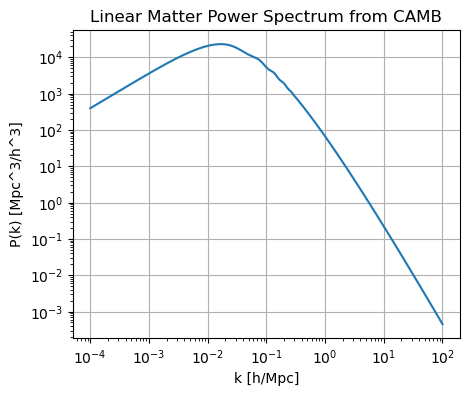

In [38]:
plt.figure(figsize=(5,4))
plt.loglog(k, P_k)
plt.xlabel("k [h/Mpc]")
plt.ylabel("P(k) [Mpc^3/h^3]")
plt.title("Linear Matter Power Spectrum from CAMB")
plt.grid()
plt.show()

NB: k piccolo=grosse scale, k grosso=piccole scale

In [39]:
#SCOPO: Calcolare la pendenza locale del grafico log-log, che equivale all’esponente della legge di potenza

logk = np.log(k)
logP = np.log(P_k)

# Spline smooth=calcolo una derivata liscia e continua
spline = UnivariateSpline(logk, logP, s=0)
dlogP_dlogk = spline.derivative()(logk)

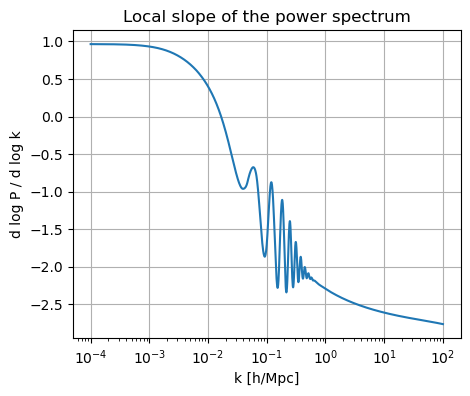

In [40]:
#questo plot dice in ogni k quale è la pendenza locale, ovvero il n effettivo
plt.figure(figsize=(5,4))
plt.plot(k, dlogP_dlogk)
plt.xscale('log')
plt.xlabel("k [h/Mpc]")
plt.ylabel("d log P / d log k")
plt.title("Local slope of the power spectrum")
plt.grid()
plt.show()

NB: osservo che la retta k^0.965 (circa 1) normalizza a k=10^-4 , invece la retta k^-3 normalizza a circa k=30 
iNVECE la retta k a 10-4 e la retta k^-3 a circa 30

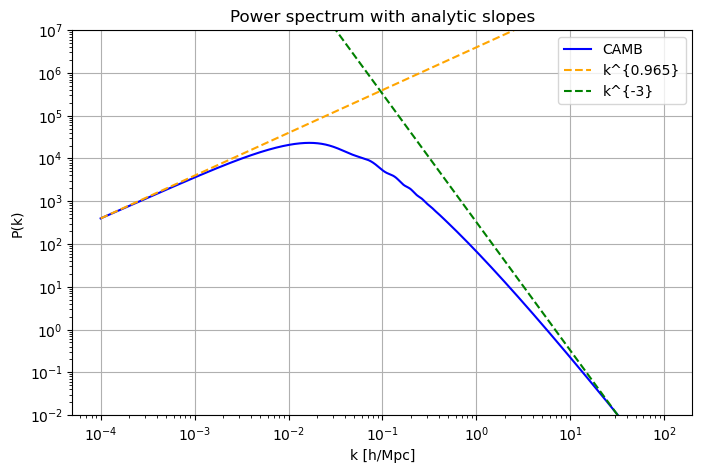

In [41]:
# Normalizzazione
k_norm_ns = 1.e-4
k_norm_kminus3 = 30

# Trovo il valore del power spectrum CAMB in quei punti
P_norm_ns = np.interp(k_norm_ns, k, P_k)
P_norm_kminus3 = np.interp(k_norm_kminus3, k, P_k)

# Costruisco le curve normalizzate
P_ns = P_norm_ns * (k / k_norm_ns)**(1)
P_kminus3 = P_norm_kminus3 * (k / k_norm_kminus3)**(-3)


plt.figure(figsize=(8,5))
plt.loglog(k, P_k, label="CAMB",color='blue')
plt.loglog(k, P_ns, '--', label="k^{0.965}",color='orange')  #scaling a grande scala
plt.loglog(k, P_kminus3, '--', label="k^{-3}",color='green')  #scaling a piccola scala
plt.xlabel("k [h/Mpc]")
plt.ylabel("P(k)")
plt.ylim(1e-2, 1e7)
plt.title("Power spectrum with analytic slopes")
plt.legend()
plt.grid()
plt.show()

ES II : MATTER POWER SENSITIVITY 

As in the previous exercise, vary cosmological parameters by 10% and compare the matter power spectrum to the reference cosmology. What is changing and why?

THEORETICAL BACKGROUND: The shape and amplitude of P(k) depend sensitively on the values of the cosmological parameters in the LambdaCDM model.

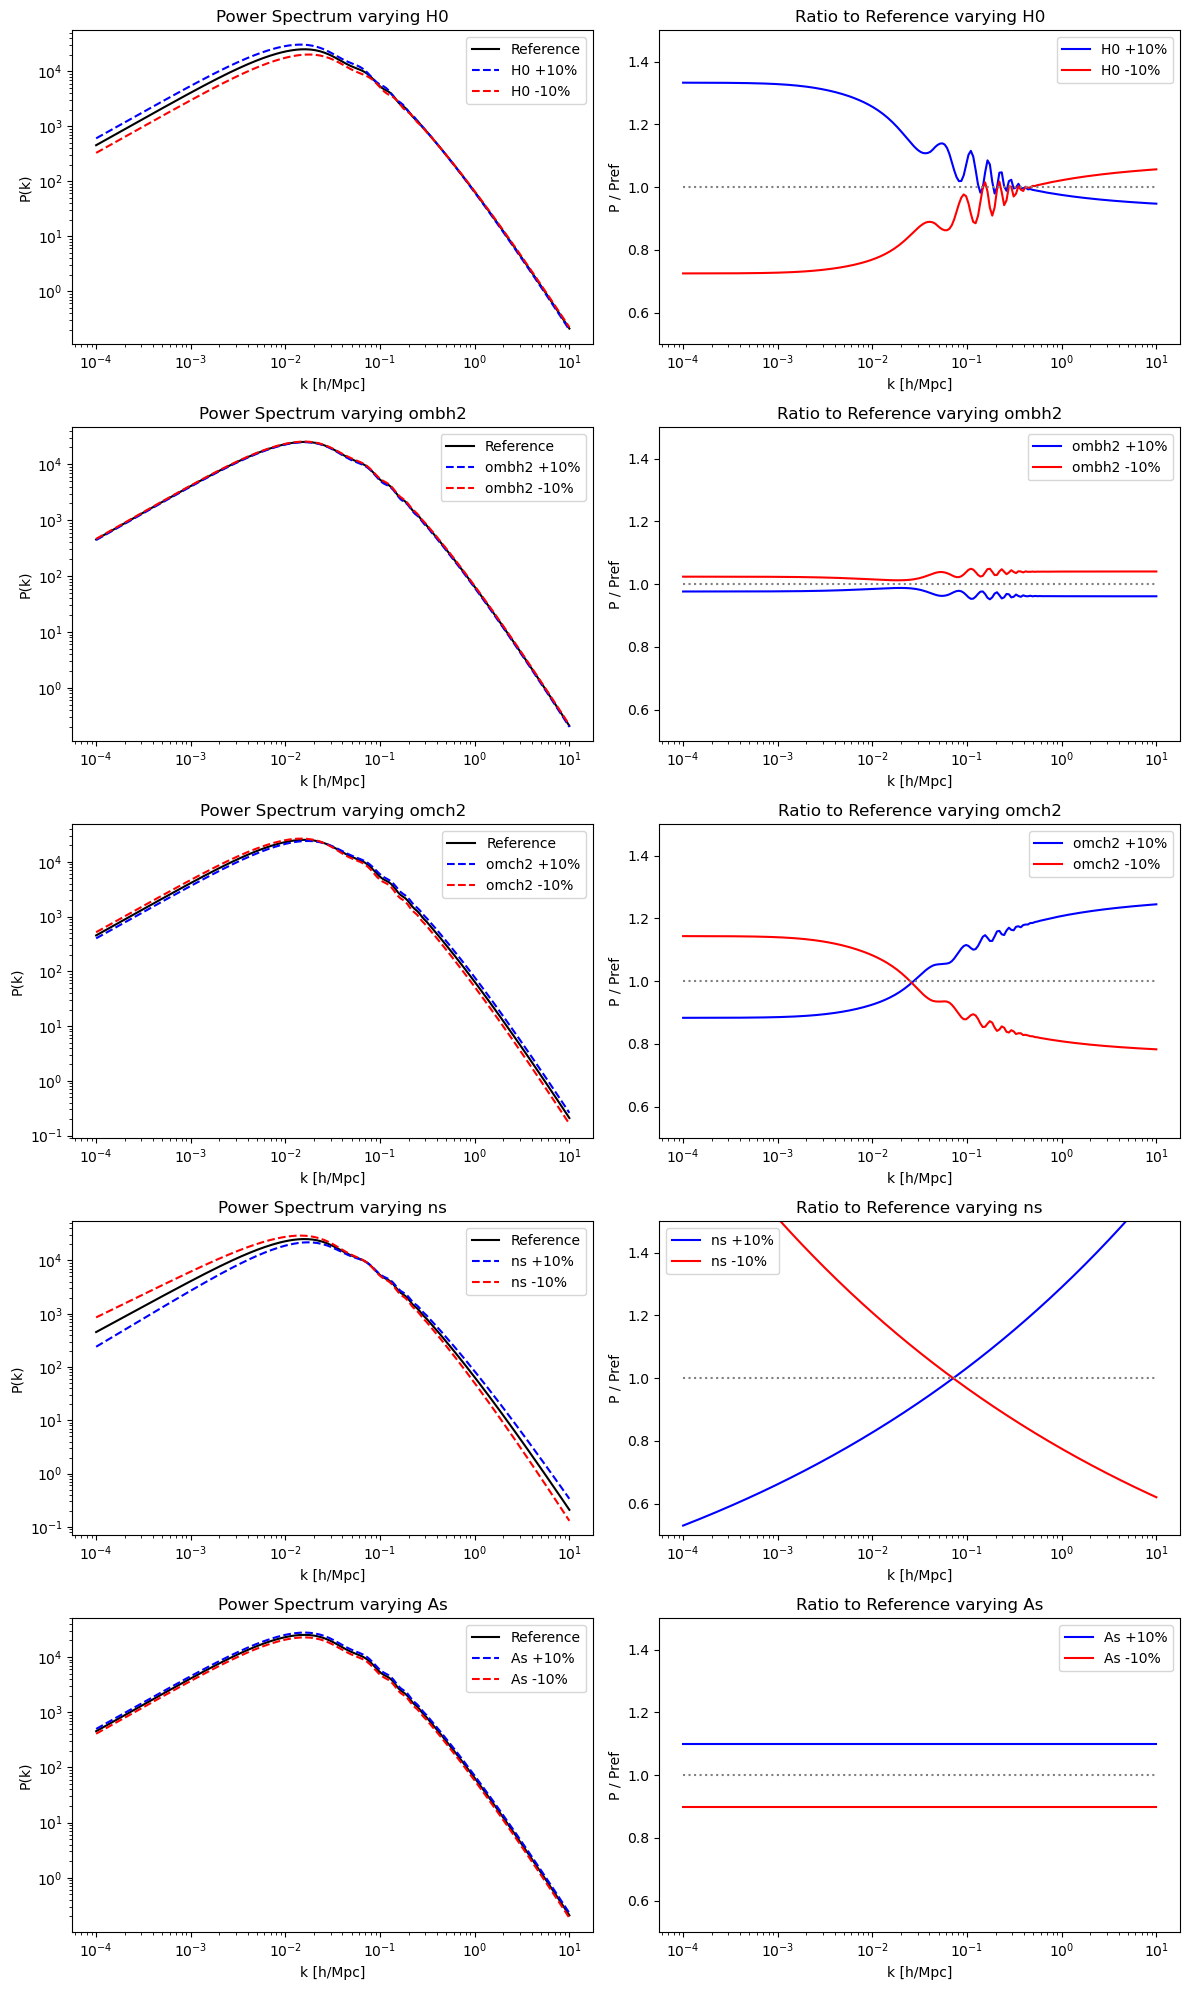

In [42]:
import camb
from camb import model, initialpower
import numpy as np
import matplotlib.pyplot as plt

# Parametri cosmologici di riferimento
cosmo_ref = {
    'H0': 70,
    'ombh2': 0.022,
    'omch2': 0.12,  
    'ns': 0.965,   # primordial spectral index
    'As': 2e-9   # amplitude of primordial power spectrum
}

# Lista dei parametri da variare
param_names = ['H0', 'ombh2', 'omch2', 'ns', 'As']

# Funzione che genera il power spectrum
def compute_pk(H0, ombh2, omch2, ns, As, kmax=10):
    pars = camb.CAMBparams()
    pars.set_cosmology(H0=H0, ombh2=ombh2, omch2=omch2)
    pars.InitPower.set_params(ns=ns, As=As)
    pars.set_matter_power(redshifts=[0], kmax=kmax)
    results = camb.get_results(pars)
    k, z, pk = results.get_matter_power_spectrum(minkh=1e-4, maxkh=kmax, npoints = 200)
    return k, pk[0]

# Calcola il riferimento (la base da variare)
k_ref, pk_ref = compute_pk(**cosmo_ref)

# Preparo la figura
fig, axs = plt.subplots(len(param_names), 2, figsize=(12, 4*len(param_names)))
fig.tight_layout(pad=4.0)

for i, p in enumerate(param_names):
    # Copia dei parametri di riferimento
    pval = cosmo_ref[p]
    
    # Variazioni +10% e -10%
    cosmo_plus = cosmo_ref.copy()
    cosmo_minus = cosmo_ref.copy()
    cosmo_plus[p] = pval * 1.1
    cosmo_minus[p] = pval * 0.9

    # Calcolo il P.S. nel nuovo set di parametri delle due situazioni
    k_plus, pk_plus = compute_pk(**cosmo_plus)
    k_minus, pk_minus = compute_pk(**cosmo_minus)

    # Asseriamo che k siano uguali
    assert np.allclose(k_ref, k_plus)
    assert np.allclose(k_ref, k_minus)

    # Grafico dei power spectrum
    axs[i,0].loglog(k_ref, pk_ref, label="Reference", color='black')
    axs[i,0].loglog(k_plus, pk_plus, '--', label=f"{p} +10%", color='blue')
    axs[i,0].loglog(k_minus, pk_minus, '--', label=f"{p} -10%", color='red')
    axs[i,0].set_xlabel("k [h/Mpc]")
    axs[i,0].set_ylabel("P(k)")
    axs[i,0].legend()
    axs[i,0].set_title(f"Power Spectrum varying {p}")

    # Grafico del rapporto: serve per capire a quali k il parametro influisce maggiormente
    ratio_plus = pk_plus / pk_ref
    ratio_minus = pk_minus / pk_ref
    axs[i,1].semilogx(k_ref, ratio_plus, label=f"{p} +10%", color='blue')
    axs[i,1].semilogx(k_ref, ratio_minus, label=f"{p} -10%", color='red')
    axs[i,1].hlines(1, k_ref[0], k_ref[-1], colors='gray', linestyles='dotted')
    axs[i,1].set_xlabel("k [h/Mpc]")
    axs[i,1].set_ylabel("P / Pref")
    axs[i,1].legend()
    axs[i,1].set_ylim(0.5, 1.5)
    axs[i,1].set_title(f"Ratio to Reference varying {p}")

plt.tight_layout()
plt.show()


MARKDOWN:  
1) se aumento H0, si riducono omegabch2 ed omegach2 (che ricordo essere: $\omega_b=\frac{omegabch2}{h^2}$) -> universo appare più dominato da radiazione in passato ->  transizione radiazione–materia avviene più tardi -> turnover (che corrisponde alla scala dell'orizzonte all’epoca di uguaglianza) avviene a scale più grandi, ovvero k più piccoli  
2) A DX:  per piccoli k ho che la curva blu (+10%) è sopra 1, ovvero la potenza aumentata rispetto al riferimento, al turnover si avvicina al riferimento e su piccole scale senbra meno sensibile ai cambi di H0  
3) se aumento omegabch2 aumenta la forza di compressione delle oscillazioni acustiche, ma poiché i barioni rappresentano solo una piccola frazione della densità totale di materia, l’effetto sull’intero P(k) è modesto  
4) A DX si osserva che ,rispetto a 2) dove al H0+10% la blu saliva sopra la rossa a piccoli k, qui la rossa è sopra ed ha senso perchè in 2) diminuiva omegabh2, mentre qui aumenta  
5) e 6) se aumento omegach2 si osserva un comportamento simile a omegabh2 ma più marcato e contrario a quello di H0 
7) ns controlla la forma iniziale dello spettro primordiale delle perturbazioni generate dall'inflazione

NB: se ns-1=0 ho spettro piatto, se ns-1<0 ho spettro red-tilded ovvero potenza maggiore a scale grandi, se ns-1>0 ho spettro blue-tilded ovvero potenza maggiore a scale piccoli  

quindi se aumento ns (0.96 diventa 1.05) sposto il potere verso le piccole scale (le fluttuazioni primordiali sono più intense a grandi k)  e lo vedo anche in 8)  
9) come visto anche nella week6, aumentare As non cambia la forma dello spettro, ma ne amplifica uniformemente l’ampiezza a tutte le scale; infatti si osserva che anche il grafico relativo (10) è del tutto piatto